<a href="https://colab.research.google.com/github/acla252/GEOG-761/blob/main/761_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab One: Question One
Amelia Clark

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [1]:
### Question 1

# Set up GEE API and initialise project
import ee
ee.Authenticate()
ee.Initialize(project='gisci341-467221')
import geemap

# Load an interactive basemap, zoomed to Aukland
Map = geemap.Map(center=(-36.8, 174.7), zoom=8) #<- Zoom to Auckland
Map.add_basemap("OpenTopoMap") #<- Add TopoMap layer

# Add a title at the top
title_html = """
<div style="position: fixed; top: 50px; left: 0; width: 100%; z-index:9999;
            text-align: center;">
    <span style="background-color: white; padding: 10px 20px;
                 border: 2px solid grey; font-size: 28px; font-weight: bold;">
        TopoMap of Auckland Region
    </span>
</div>
"""
Map.add_html(title_html)

# Add a north arrow
north_arrow_html = """
<div style="position: fixed; bottom: 100px; left: 100px; z-index:9999;
background-color: white; padding: 5px 10px; border:2px solid grey;
font-size: 20px; font-weight: bold; text-align: center;">
N &#x2191;
</div>
"""
Map.add_html(north_arrow_html)

# Display the map
Map

Map(center=[-36.8, 174.7], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

# Lab One: Question Three

(3) Correct the display of the Landsat 7 image so that it displays in 'True Colour'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [2]:
### Question 3

# Set up GEE API and initialise project
import ee
ee.Authenticate()
ee.Initialize(project='gisci341-467221')
import geemap

# Centre on New Zealand, zoom out so you can see the whole country
Map = geemap.Map(center=(-41.688, 172.841), zoom=5)

# Add Earth Engine Landsat7 dataset
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")

# Visualise the spectral bands, making sure to adjust the bands, min, max, and gamma
viz_params_sr = {
    'bands': ['B3', 'B2', 'B1'],
    'min': 10,
    'max': 55,
    'gamma': 1.4
}

# Add the visualisation layer
Map.addLayer(landsat7, viz_params_sr, 'Landsat 7 True Colour')

# Add a title at the top
title_html = """
<div style="position: fixed; top: 30px; left: 0; width: 100%; z-index:9999;
            text-align: center;">
    <span style="background-color: white; padding: 10px 20px;
                 border: 2px solid grey; font-size: 28px; font-weight: bold;">
        Landsat 7 True Colour Image of New Zealand
    </span>
</div>
"""
Map.add_html(title_html)

# Add a north arrow
north_arrow_html = """
<div style="position: fixed; bottom: 100px; left: 100px; z-index:9999;
background-color: white; padding: 5px 10px; border:2px solid grey;
font-size: 20px; font-weight: bold; text-align: center;">
N &#x2191;
</div>
"""
Map.add_html(north_arrow_html)

# Display the map
Map


Map(center=[-41.688, 172.841], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

# Lab One: Question Seven

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [3]:
### Question 7

# Set up GEE API and initialise project
import ee
ee.Authenticate()
ee.Initialize(project='gisci341-467221')
import pandas as pd

# Create a region of interest, a 1000m buffer around the center of Queenstown
queenstown_pt = ee.Geometry.Point([168.6626, -45.0312])
roi = queenstown_pt.buffer(1000).bounds()

# Mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Make a cloud calculation function to use later
def get_image_cloud_stats(image):
    # Total area (pixels)
    pixel_area = ee.Image.pixelArea().clip(roi)
    stats = pixel_area.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=roi,
        scale=30
    )
    total = ee.Number(stats.get('area'))

    # Valid pixels are the non-cloudy ones
    masked = mask_clouds(image)
    valid_stats = masked.select('SR_B3').reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=roi,
        scale=30
    )
    valid = ee.Number(valid_stats.get('SR_B3'))

    # Calculate percentage cloudy
    # % = (1-valid/total)*100
    pct = ee.Number(1).subtract(valid.divide(total)).multiply(100)
    return image.set('cloud_percentage', pct)

# Process years 2005, 2010, and 2015
years = [2005, 2010, 2015]
summary_data = []

# Loop through the 3 years
for year in years:
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'

    # Load collection for the year
    col = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
        .filterBounds(roi) \
        .filterDate(start_date, end_date)

    # Map calculation and get average
    avg_cloud = col.map(get_image_cloud_stats).aggregate_mean('cloud_percentage').getInfo()
    summary_data.append({
        'Year': year,
        'Average Cloud Cover in Queenstown (%)': round(avg_cloud, 2)
    })


# Create and display the table
cloud_summary_df = pd.DataFrame(summary_data)
display(cloud_summary_df)

,Year,Average Cloud Cover in Queenstown (%)
0,2005,72.11
1,2010,72.18
2,2015,60.32


# Lab One: Question Eight

(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:

Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.

Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.

Gives examples of the sample areas that you have used to create these spectral signatures.



Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:

It is at a good quality (resolution) and not blurry.

The font size of all elements is big enough to read easily on a screen when placed in the document.

Has a figure caption that ensures the reader knows what you have done and why.

Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)

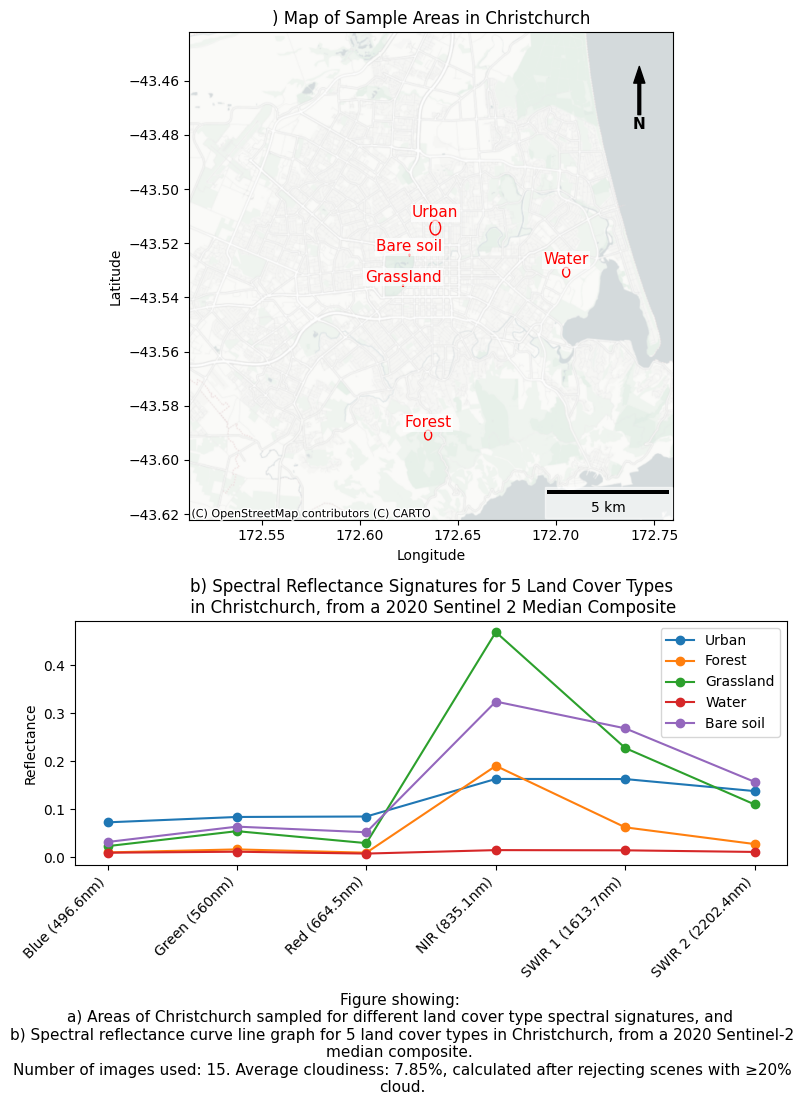

In [4]:
### Question 8

# Set up GEE API and initialise project
import ee
ee.Authenticate()
ee.Initialize(project='gisci341-467221')
!pip install contextily matplotlib_scalebar
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as cx
import numpy as np

# Define the center of Christchurch, New Zealand
christchurch_center = ee.Geometry.Point([172.6362, -43.5321])

# Create a buffer that approximates the city bounds (10km radius)
roi = christchurch_center.buffer(10000).bounds()

# Mask clouds using QA_PIXEL band
def mask_s2_clouds(image):

  qa = image.select('QA60')

  # Bits 10 and 11 are clouds and cirrus
  cloud_bit_mask = 1 << 10
  cirrus_bit_mask = 1 << 11

  # Both flags set to zero, indicating clear conditions
  mask = (
      qa.bitwiseAnd(cloud_bit_mask)
      .eq(0)
      .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
  )

  return image.updateMask(mask).divide(10000)


# Select the Sentinel-2 images that will be used
filtered_col = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2021-01-01')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
)

# Report how many images and their average cloudiness
num_images = filtered_col.size().getInfo()

avg_cloud = filtered_col.aggregate_mean(
    'CLOUDY_PIXEL_PERCENTAGE'
).getInfo()

# Now apply the pixel-level cloud masking
col = filtered_col.map(mask_s2_clouds)

# Create the presented the Figure

# Load Sentinel 2 surface reflectance image
# Define bands and scaling
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
band_names = {
    'B2': 'Blue (496.6nm)',
    'B3': 'Green (560nm)',
    'B4': 'Red (664.5nm)',
    'B8': 'NIR (835.1nm)',
    'B11': 'SWIR 1 (1613.7nm)',
    'B12': 'SWIR 2 (2202.4nm)'
}
labels = list(band_names.values())
scale_factor = 0.0001

# Use all suitable observations rather than one scene
reflectance_composite = col.median()

# Make a function to get the spectral reflectance values
def getReflectance(region):
    mean_dict = reflectance_composite.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=30,
        maxPixels=1e7
    ).getInfo()
    values = [mean_dict.get(b) for b in bands]
    # Values have already been scaled in prepare_sentinel()
    return values


# Define 5 different regions using examples from Christchurch
covertype_regions = {
    'Urban' : ee.Geometry.Point([172.638507, -43.514241]).buffer(300).bounds(),
    'Forest' : ee.Geometry.Point([172.634857, -43.590829]).buffer(200).bounds(),
    'Grassland' : ee.Geometry.Point([172.622069, -43.535630]).buffer(30).bounds(),
    'Water' : ee.Geometry.Point([172.705166, -43.530726]).buffer(200).bounds(),
    'Bare soil' : ee.Geometry.Point([172.625352, -43.524320]).buffer(30).bounds()
}

reflectance_results = {}
for cover_type, region in covertype_regions.items():
    vals = getReflectance(region)
    if None not in vals:
        reflectance_results[cover_type] = vals
    else:
        print(f"Warning: Could not extract valid reflectance for {cover_type}")

# Get coordinates of region
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

xmin, xmax, ymin, ymax = get_bounds_coords(roi)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)
cx.add_basemap(ax1, source=cx.providers.CartoDB.PositronNoLabels, crs='EPSG:4326')
ax1.set_title(") Map of Sample Areas in Christchurch")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# Our image is lat/long, so ensure that our aspect ratio is correct
mean_lat = (ymin + ymax) / 2
ax1.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))

# Add north arrow
ax1.annotate(
    'N',
    xy=(0.93, 0.93),
    xytext=(0.93, 0.81),
    xycoords='axes fraction',
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    arrowprops={
        'facecolor': 'black',
        'edgecolor': 'black',
        'width': 2,
        'headwidth': 8
    }
)

# Add a scale bar
# Approximate kilometres represented by one degree of longitude
km_per_degree_lon = 111.32 * np.cos(np.deg2rad(mean_lat))
scalebar = ScaleBar(
    km_per_degree_lon,
    units="km",
    fixed_value=5,
    fixed_units="km",
    location="lower right",
    box_alpha=0.6,
    color="black"
)
ax1.add_artist(scalebar)

# Add and label the five cover-type regions
for cover_type, region in covertype_regions.items():
    cxmin, cxmax, cymin, cymax = get_bounds_coords(region)
    center_x = (cxmin + cxmax) / 2
    center_y = (cymin + cymax) / 2
    radius = min(cxmax - cxmin, cymax - cymin) / 2

    cover_circle = patches.Circle(
        (center_x, center_y),
        radius,
        linewidth=1,
        edgecolor='red',
        facecolor='none'
    )
    ax1.add_patch(cover_circle)

    ax1.text(
        center_x,
        cymax,
        cover_type,
        color='red',
        fontsize=11,
        ha='center',
        va='bottom',
        bbox={
            'facecolor': 'white',
            'alpha': 0.7,
            'edgecolor': 'none',
            'pad': 1
        }
    )

for cover_type, values in reflectance_results.items():
    ax2.plot(labels, values, marker='o', label=cover_type)

ax2.set_title("b) Spectral Reflectance Signatures for 5 Land Cover Types\n in Christchurch, from a 2020 Sentinel 2 Median Composite")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.legend()
ax2.grid(False)

# Add a summary info
summary = (
    f"Figure showing: \n"
    F"a) Areas of Christchurch sampled for different land cover type spectral signatures, and \n"
    f"b) Spectral reflectance curve line graph for 5 land cover types in Christchurch, "
    f"from a 2020 Sentinel-2 median composite. \n"
    f"Number of images used: {num_images}. Average cloudiness: {avg_cloud:.2f}%, calculated after rejecting scenes with ≥20% cloud."
)
fig.text(0.5, -0.1, summary, ha="center", va="bottom", fontsize=11, wrap=True)

plt.tight_layout()

# Save the image
plt.savefig("/content/GEOG761_Lab1_Q8.png", dpi=300, bbox_inches="tight")
plt.show()